# Customer Churn Analysis

## Importing Libraries and Dataset

In [33]:
#Exploratory Descriptive Analysis(EDA), Dataset import
import pandas as pd
#Mathametical Operation
import numpy as np
#To devide the training set and test set
from sklearn.model_selection import train_test_split #scikit-learn -> machine learning package/library ... model_selection is the submodule. and in this model selection there is an funcion called train_test_split.. by this we just import train_test_split
#imbalance learning -> The result are should be more or less 50%. this will do the synthetic oversampling. minority group create more. and it is and synthetic process.
from imblearn.over_sampling import SMOTE #SMOTE -> Synthetic Minority Oversampling Technique
#if someone churn, why he did this, which indepancnce factor is the most important. it determine to identifying the indepandance factor
import shap

### importing dataset


In [34]:
dataset = pd.read_csv("Customer-Churn.csv")

## Exploratory Descritive Analysis (EDA)

### Checking the numbers of rows and columns of a dataset

In [35]:
dataset.shape

(7043, 21)

### Checking the data types and non null counts


Null count --> missing value count

In [36]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Checking the missing value

In [37]:
dataset.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Checking the descriptive statistics for the numeric columns

In [38]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [39]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Checking the categorical feature distribution

In [40]:
#in number
dataset["Contract"].value_counts()
#in proportion
dataset["Contract"].value_counts(normalize=True)

,proportion
Contract,
Month-to-month,0.550192
Two year,0.240664
One year,0.209144


In [41]:
dataset.PaymentMethod.value_counts(normalize=True)

,proportion
PaymentMethod,
Electronic check,0.335794
Mailed check,0.228880
Bank transfer (automatic),0.219225
Credit card (automatic),0.216101


### Checking the numeric feature distribution

<Axes: >

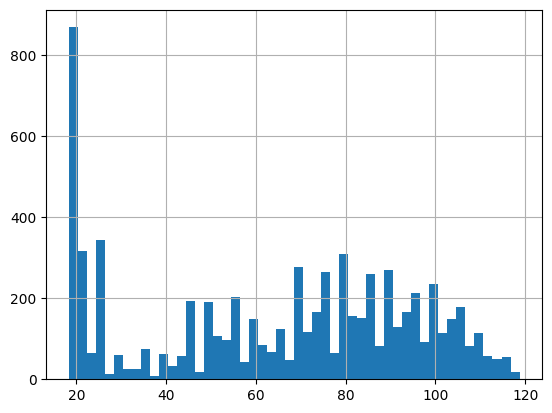

In [42]:
dataset['MonthlyCharges'].hist(bins=50)

<Axes: >

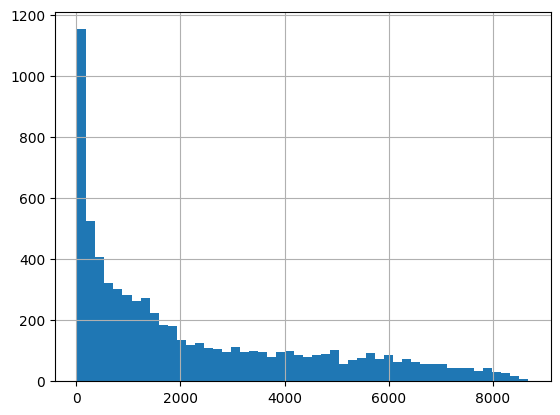

In [81]:
dataset['TotalCharges'].hist(bins=50)

### Crosstabs analysis

Two column using for frequency analysis

In [44]:
# Chrun vs. Contract type
pd.crosstab(dataset["Contract"],dataset["Churn"], normalize= "index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [45]:
# Churn vs. Tenure
dataset["tenure_group"] = pd.cut(dataset["tenure"], bins=[0,6,12,24,48,72],
                                 labels= ["0-6","7-12","13-24","25-48","49-72"])
pd.crosstab(dataset["tenure_group"],dataset["Churn"], normalize= "index")

Churn,No,Yes
tenure_group,,
0-6,0.466667,0.533333
7-12,0.641135,0.358865
13-24,0.712891,0.287109
25-48,0.796110,0.203890
49-72,0.904868,0.095132


## Data Preprocessing (Part-1)

### Checking Imbalanced Dataset

In [46]:
#count the value of the specific column
dataset["Churn"].value_counts()
#See in proportion in percentage.. Num/Total
dataset["Churn"].value_counts(normalize= True)

,proportion
Churn,
No,0.73463
Yes,0.26537


### Data Cleaning

#### Detecting the erroneous numeric columns by calculating the mean

**Task:-**

    You need to check a independent column in the dataset for errors.

**What to check:-**

**1. Missing values**

    Find if the column has any NA or empty values.

**2. Spacing mistakes**

    Check if the data has extra spaces at the start or end.

**3. Mean calculation**

    Try to calculate the mean of the column.

    If the mean is not shown, that means the column has an error (maybe text, spaces, or wrong data type).

In [47]:
print(dataset["tenure"].mean())
print(dataset["MonthlyCharges"].mean())

32.37114865824223
64.76169246059918


In [48]:
#to check there any missing value in the column.
#print(dataset["TotalCharges"].mean())

#### Converting the string entries to numeric and NaN

In [49]:
# Not a Number --> NaN
# Make the string to numeric
# if there the data cannot convert into the the numaric then it will convert into NaN
# error = "coerce" -> when find the string make it NaN. if any value can’t be converted (like text or blank), make it NaN instead of giving an error.
dataset["TotalCharges"] = pd.to_numeric(dataset["TotalCharges"], errors = "coerce")

In [50]:
#checking mean of the Total Charges
print(dataset["TotalCharges"].mean())
#as it shows the mean. that's means the column is clean now.

2283.3004408418656


#### Dropping the nan-containing rows from the dataframe

In [51]:
dataset.shape

(7043, 22)

In [52]:
# Now we will delete the data which is missing.
# In machine learning we will not fill the missing value. As the dataset is huge. We will not do data manupulation.
dataset = dataset.dropna(subset = ["TotalCharges"]).copy()

In [53]:
dataset.shape

(7032, 22)

## Data preprocessing (Part-2)

### Removing unneccessary features

**Concept**


    In machine learning, independent variables are usually stored in a variable named X.

    X is created by selecting all the independent (input) features from the dataset.

    X is also called the feature matrix, because it holds all the columns used to predict the target.



In [54]:
X = dataset.drop(columns=["customerID", "Churn"])

### Dependent variable decleration

In [55]:
y = dataset["Churn"]

The machine learning algorithm cannot work on the string file. Now we need to do Numeric encoding.

In [56]:
#dictorary --> {'key1':value1, 'key1':value1}
y = y.map({'No':0, 'Yes':1})

### Spliting the dataset into the trainging set and test set

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

1. test_size = 0.2

        20% of data goes to test

        80% goes to train

2. random_state = 42

        Fixes the randomness

        You will always get the same split every time you run it

3. stratify = y

        Keeps the same class ratio in both train and test

## Data Preprocessing (Part-3)

### One-hot encoding

**Vector Encoding & Dummy Variables**

    Machine learning models cannot read text, so we must convert all categorical text into numbers.

    But we cannot convert categories as 1, 2, 3, 4 because it creates a false ranking (model thinks 4 > 1).

    Categorical data has no order, so we avoid direct numbering.

**Independent Variables Have Two Types**

    Categorical → text labels

    Numerical → numbers

    Both types must be checked before training.

**For Categorical Variables**

    Convert them using Dummy Variables (One-Hot Encoding).

    Each category becomes a new column with 0/1 values.

    Example (Color):
    This is an example of One Hot encoder
| Color_Red | Color_Blue | Color_Green | Color_Yellow |
| --------- | ---------- | ----------- | ------------ |
| 1         | 0          | 0           | 0            |
| 0         | 1          | 0           | 0            |
| 0         | 0          | 1           | 0            |
| 0         | 0          | 0           | 1            |
| 1         | 0          | 0           | 0            |
| 0         | 0          | 1           | 0            |


    Even Binary Categories (like 0/1) Should Be Treated as Categorical

    Example: “Partner: 0 = No, 1 = Yes”

    It is still categorical, not numerical.

    So convert it into dummy columns to avoid wrong interpretation.



Nummeric column -> freature endocing -> scale fix.


In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

#### Selecting the numeric column and catagorical column

In [59]:
num_cols = X.select_dtypes(include = np.number).columns.tolist()

#### Selecting the categorical columns

In [60]:
cat_cols = X.select_dtypes(exclude = np.number).columns.tolist()

#### Columns Trasformations

**handle_unknown = "ignore" --> If a new category appears, ignore it (no error).**
    
    handle_unknown="ignore" tells OneHotEncoder to skip any category not seen in training.
    Unknown categories in test data get all zeros in the encoded columns.
    This prevents errors without adding new columns

**sparse output**


In [61]:
pre = ColumnTransformer(
    transformers = [
        ("cata", OneHotEncoder(handle_unknown = "ignore", sparse_output= False), cat_cols),
        ("numb", "passthrough", num_cols)
    ]
)

In [62]:
pre.fit_transform(X_train)

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 6.50000e+01,
        9.45500e+01, 6.07875e+03],
       [0.00000e+00, 1.00000e+00, 1.00000e+00, ..., 2.60000e+01,
        3.57500e+01, 1.02250e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 6.80000e+01,
        9.02000e+01, 6.29765e+03],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 3.60000e+01,
        9.29000e+01, 3.37925e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+01,
        6.59000e+01, 6.60050e+02],
       [0.00000e+00, 1.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.47000e+01, 7.47000e+01]])

## Data Preprocessing (Part-4)

### Getting names of encoded categorical columns

In [63]:
cat_iv_names = pre.named_transformers_["cata"].get_feature_names_out(cat_cols)

### Combining the categorical columns with the numeric columns

In [64]:
all_iv_names = list(cat_iv_names) + num_cols

### Converting the transformed output to a DataFrame

In [65]:
X_trasformed = pre.fit_transform(X)

**pandas convert the array to the dataframe**

In [66]:
tr_df = pd.DataFrame(X_trasformed, columns = all_iv_names)


## Training the Baseline Model

### Training the baseline model

1. **Supervised Learning**

    We already know:

    *   Input (independent variables)
    *   Output (dependent variable)
    Data is labeled

    We give the model examples, it learns patterns, and predicts output.


    Two types:

          a) Regression
          Output is continuous / numerical

          Examples:
          Predict house price based on size
          Forecast monthly income
          Predict temperature, rainfall amount
          Estimate crop yield

          b) Classification
          Output is categories / classes (not continuous)

          Examples:

          Spam vs Non-spam email
          Yes/No loan approval
          Disease positive or negative
          Classifying types of fruits (apple, orange, banana)

2. **Unsupervised Learning**

        No dependent variable
        Data has no labels
        Model finds patterns on its own


        Most common example: Clustering
        Customer segmentation (grouping buyers by habits)
        Grouping similar images without label
        Market basket analysis (which items are often bought together)

3. **Reinforcement Learning**

        Learning by trial and error
        System gets reward for right actions and punishment/negative score for wrong ones
        Tries to maximize reward over time

        Examples
        Training a robot to walk
        Game AI (Chess, Go, Mario bot)
        Self-driving car deciding speed and direction

**Pipeline in Machine Learning**

    Not mandatory, but very helpful
    Makes workflow organized and reliable
    Handles all preprocessing steps in a fixed order
    Reduces human mistakes and data leakage
    Keeps train and test processing consistent
    Helps build cleaner and reusable code
    Improves reliability of model results

In [67]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


**Maximum Iteration (max_iter)**

    During training, the model sees the data again and again.
    max_iter = how many times the model is allowed to learn from the data.
    More iterations → model learns longer and may perform better.
    Important when dataset is large or learning is slow.
    If max_iter is too low → model may stop early (underfit / not fully trained)
    If too high → takes more time and may overfit.

In [68]:
pipe_lr = Pipeline([
    ("preprocessing", pre),
    ("classification", LogisticRegression(max_iter=3000, class_weight='balanced')) # class_weight = "balance" -> automatically increases the importance of the minority class.
])
pipe_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cata',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'tenure_group']),
                                                 ('numb', 'passthrough',
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('classification',
                 LogisticRegression(class_weight='balanced', max_iter=3000))])

##  Model Evaluation (Part 1)



In [69]:
y_pred = pipe_lr.predict(X_test)

In [70]:
from sklearn.metrics import confusion_matrix , accuracy_score

In [71]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[731, 302],
       [ 73, 301]])

|          | Predicted 0 | Predicted 1 |
| -------- | ----------- | ----------- |
| Actual 0 | 723         | 310         |
| Actual 1 | 76          | 298         |

**Meaning of each value:**

    True Negative (TN) = 723 → correctly predicted 0
    False Positive (FP) = 310 → wrongly predicted 1 while actually 0
    False Negative (FN) = 76 → wrongly predicted 0 while actually 1
    True Positive (TP) = 298 → correctly predicted 1

Accuracy = (number of correct predictions) ÷ (total number of predictions)

Written as a formula:

    Accuracy =
    (TP + TN) / (TP + TN + FP + FN)

In [72]:
accuracy_score(y_test, y_pred)

0.7334754797441365

## Model Evaluation (Part-2)

In [73]:
y_proba_pred = pipe_lr.predict_proba(X_test)[:, 1]
print(y_proba_pred[:10])

[0.0572049  0.74961692 0.02030449 0.44218487 0.22698938 0.74123616
 0.07336916 0.2618497  0.80557271 0.0726763 ]


In [74]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_proba_pred)
print(roc_auc)

0.8370756997685987


### 🔧 Code to Plot ROC Curve

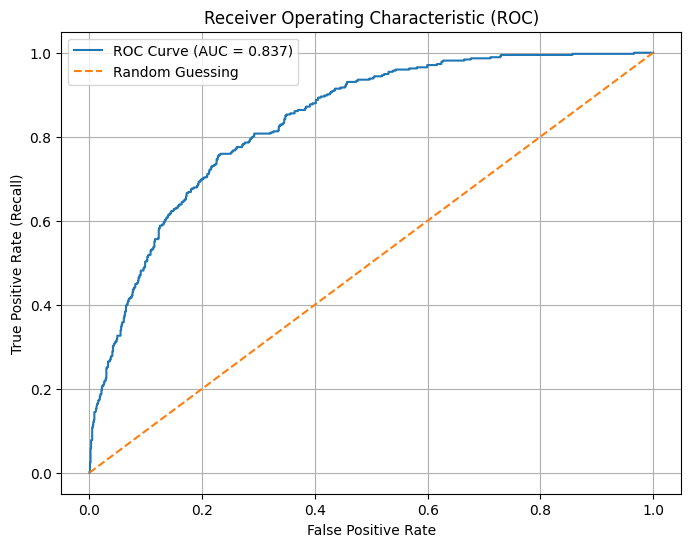

In [75]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_proba_pred)

# AUC score
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guessing')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend()
plt.grid(True)
plt.show()


###  Check the significant churn predictors using coefficients

In [76]:
main_model = pipe_lr.named_steps['classification']
main_model.coef_[0]

array([-1.11993391e-02, -2.58684890e-02, -1.19465386e-02, -2.51212894e-02,
        8.37625962e-02, -1.20830424e-01,  7.58378837e-02, -1.12905712e-01,
       -2.34309683e-01,  7.58378837e-02,  1.21403972e-01, -4.25099477e-01,
        5.24738389e-01, -1.36706740e-01,  2.24768282e-01, -1.36706740e-01,
       -1.25129370e-01,  1.21416209e-01, -1.36706740e-01, -2.17772972e-02,
        1.61557853e-02, -1.36706740e-01,  8.34831265e-02,  2.05832567e-01,
       -1.36706740e-01, -1.06193655e-01, -1.18363362e-01, -1.36706740e-01,
        2.18002274e-01, -1.06962165e-01, -1.36706740e-01,  2.06601077e-01,
        8.10132399e-01, -9.27399258e-03, -8.37926235e-01, -1.44043006e-01,
        1.06975178e-01, -1.32650416e-01, -4.95342175e-02,  2.62084543e-01,
       -1.16967738e-01,  6.28741922e-01, -2.60924163e-01, -2.84297479e-01,
       -6.92771313e-02, -5.13109771e-02,  2.13726341e-01, -2.60791066e-02,
       -2.75293659e-03,  5.43617405e-05])

1D Array:

    One line of values.

    Example:
    [10, 20, 30, 40]

    Access: arr[2] → 30

    Works like one DataFrame column.

2D Array:

    Table with rows and columns.

    Example:
    [
    [10, 20, 30],
    [40, 50, 60]
    ]

    Access: arr[1][2] → 60

    Built from multiple 1D arrays.


In [77]:
coef = pipe_lr.named_steps['classification'].coef_[0]

importance_df = pd.DataFrame({
    'features':all_iv_names,
    'coeficients':coef
    }).sort_values(by = 'coeficients', ascending = False, key = abs)

In [78]:
importance_df

,features,coeficients
34,Contract_Two year,-0.837926
32,Contract_Month-to-month,0.810132
41,tenure_group_0-6,0.628742
12,InternetService_Fiber optic,0.524738
11,InternetService_DSL,-0.425099
43,tenure_group_25-48,-0.284297
39,PaymentMethod_Electronic check,0.262085
42,tenure_group_13-24,-0.260924
8,MultipleLines_No,-0.234310
14,OnlineSecurity_No,0.224768


###  Check the significant churn predictors using shap

In [79]:
import shap

model = pipe_lr.named_steps['classification']
X_transformed = pre.transform(X_test)

explainer = shap.LinearExplainer(model, X_transformed)
shap_values = explainer.shap_values(X_transformed)

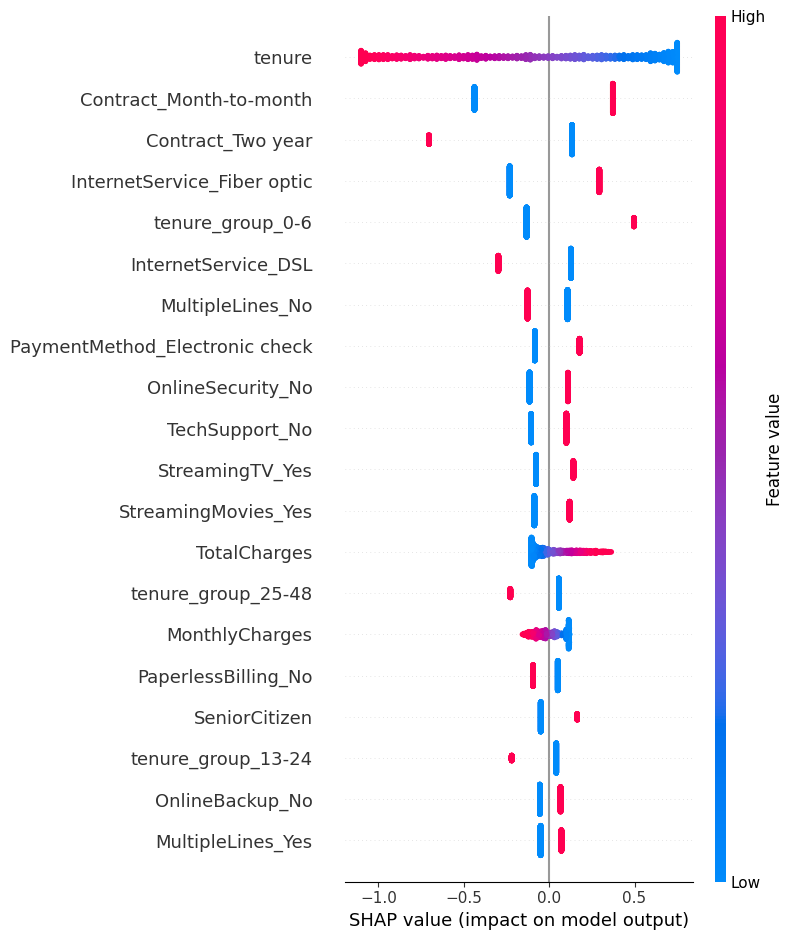

In [80]:
shap.summary_plot(shap_values, X_transformed, feature_names = all_iv_names)

**Coefficients vs SHAP Importance**

1. They Measure Different Things

    Coefficients = rate of change (impact of a 1-unit increase)

    SHAP values = total impact on prediction (overall contribution)

2. The “Unit Size” Problem

    A coefficient only shows the effect of increasing a variable by 1 unit.

    Categorical Example (Fiber Optic)

    Changing 0 → 1 is a full jump (100% change)

    Coefficient may be 0.87

    Total impact = 1 × 0.87 = 0.87

    Continuous Example (Tenure)

    Coefficient may be small, like −0.06

    But tenure ranges from 0 to 72 months

    So total impact =
    70 × (−0.06) = −4.2

    Even though −0.06 looks small, multiplying by a large range creates a much bigger total effect.

3. Quick Summary

    Logistic coefficients tell you:
    “If I increase this feature by 1 unit, how does the log-odds change?”

    SHAP values tell you:
    “How much does this feature actually influence predictions across the dataset?”

    Therefore, SHAP importance often flips the order you see in coefficients.

Need to correct the senior senizen!!!